In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
import requests
import io

Load dSprites Dataset

In [3]:
class dSpritesDataset(Dataset):
    """Load dSprites dataset without keeping everything in memory"""
    def __init__(self):
        url = "https://github.com/deepmind/dsprites-dataset/raw/master/dsprites_ndarray_co1sh3sc6or40x32y32_64x64.npz"
        response = requests.get(url)
        dataset_zip = np.load(io.BytesIO(response.content), allow_pickle=True)
        self.data = dataset_zip['imgs']  # Keep only references, not full data
        self.length = len(self.data)

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        img = torch.tensor(self.data[idx], dtype=torch.float32).unsqueeze(0)  # Load only 1 image at a time
        return img, img  # Input = Output (unsupervised learning)


Define the Variational Autoencoder

In [4]:
class VAE(nn.Module):
    def __init__(self, latent_dim=10):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder (CNN)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),  # 64x64 -> 32x32
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 32x32 -> 16x16
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 16x16 -> 8x8
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),  # 8x8 -> 4x4
            nn.ReLU(),
            nn.Flatten()
        )

        # Fully connected layers to get mean and log-variance
        self.fc_mu = nn.Linear(4*4*256, latent_dim)  # Mean of the latent space
        self.fc_logvar = nn.Linear(4*4*256, latent_dim)  # Log-variance of the latent space

        # Decoder (CNN)
        self.decoder_fc = nn.Linear(latent_dim, 4*4*256)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # 4x4 -> 8x8
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 8x8 -> 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 16x16 -> 32x32
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),  # 32x32 -> 64x64
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        """Applies the reparameterization trick"""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        """Pass data through the VAE"""
        x = self.encoder(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        z = self.reparameterize(mu, logvar)
        x = self.decoder_fc(z).view(-1, 256, 4, 4)
        x = self.decoder(x)
        return x, mu, logvar



Loss Function (VAE loss)

In [ ]:
def vae_loss(recon_x, x, mu, logvar):
    """Computes VAE loss: Reconstruction loss + KL Divergence"""
    recon_loss = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())  # KL loss
    return recon_loss + kl_divergence

Training the VAE

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 10  # Size of the latent space
vae = VAE(latent_dim).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

# Load dataset
dataset = dSpritesDataset()
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

num_epochs = 20
for epoch in range(num_epochs):
    train_loss = 0
    for x, _ in dataloader: 
        x = x.to(device)
        optimizer.zero_grad()
        recon_x, mu, logvar = vae(x)
        loss = vae_loss(recon_x, x, mu, logvar)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {train_loss / len(dataloader.dataset):.4f}")

Epoch 1, Loss: 4.2394


Generate and Visualize Samples

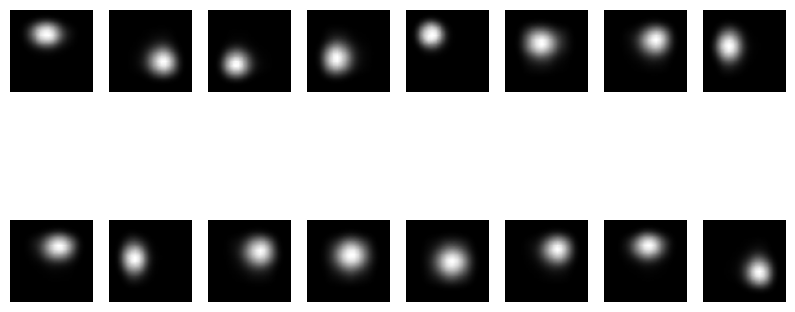

In [9]:
vae.eval()
with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    generated_images = vae.decoder(vae.decoder_fc(z).view(-1, 256, 4, 4))
    generated_images = generated_images.cpu().numpy()

fig, axes = plt.subplots(2, 8, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_images[i, 0], cmap='gray')
    ax.axis('off')
# plt.savefig("vae_generated.png")  # Save instead of showing
# print("Plot saved as 'vae_generated.png'. Open it manually.")
plt.show()

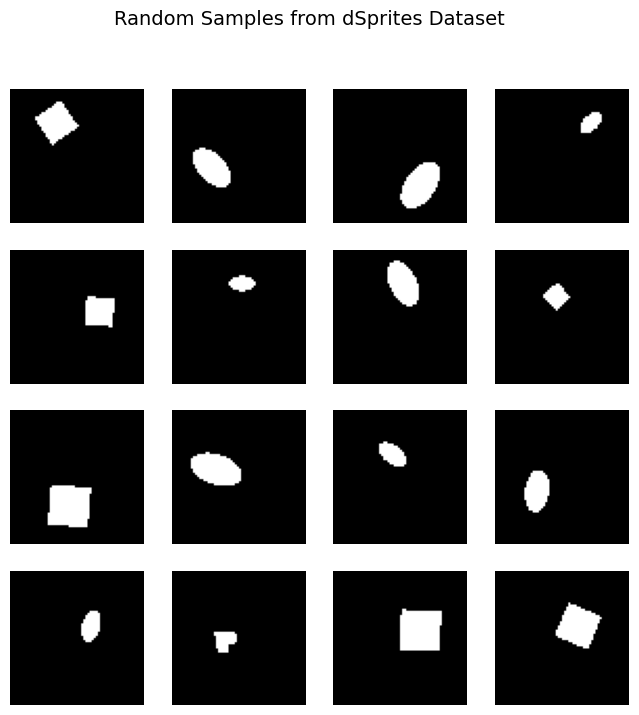

: 

In [ ]:
# ==============================
# Load dSprites Dataset
# ==============================
def load_dsprites():
    """Download and load the dSprites dataset."""
    url = "https://github.com/deepmind/dsprites-dataset/raw/master/dsprites_ndarray_co1sh3sc6or40x32y32_64x64.npz"
    response = requests.get(url)
    dataset_zip = np.load(io.BytesIO(response.content), allow_pickle=True)
    return dataset_zip['imgs']

# ==============================
# Visualization Function
# ==============================
def visualize_dsprites(images, num_images=16):
    """
    Visualizes a grid of dSprites images.

    Args:
        images (numpy.ndarray): dSprites dataset images (shape: [N, 64, 64]).
        num_images (int): Number of images to display (default=16).
    """
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))  # 4x4 grid
    indices = np.random.choice(images.shape[0], num_images, replace=False)  # Select random indices

    for i, ax in enumerate(axes.flat):
        ax.imshow(images[indices[i]], cmap='gray')  # Show image
        ax.axis('off')  # Hide axes

    plt.suptitle("Random Samples from dSprites Dataset", fontsize=14)
    plt.show()

# ==============================
# Load and Display dSprites Images
# ==============================
dsprites_images = load_dsprites()  # Load dataset
visualize_dsprites(dsprites_images)  # Show 16 images


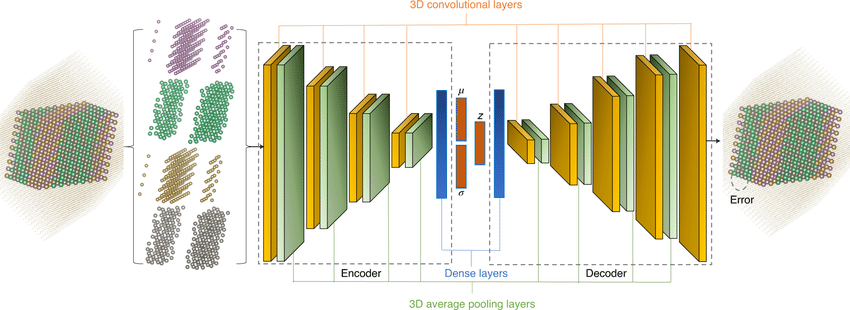